In [19]:
from L1_DifferentialEvolution import extract_data, model, diff_evolution
from scipy.optimize import Bounds
from scipy.optimize import minimize
from NelderMead_rounded import rounded_nelder_mead
from losses_bayesian import Losses
from matplotlib.animation import PillowWriter
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import math
import physics
import numpy as np
import matplotlib.pyplot as plt

frequency, intensity = extract_data() # extracting the desired information

# compressor parameters - obtained as minus the stretcher one - TO BE FIXED WITH REAL ONES ONCE THEY ARE AVAILABLE
COMPRESSOR = -1 * np.array((267.422 * 1e-24, -2.384 * 1e-36, 9.54893 * 1e-50)) # in s^2, s^3 and s^4 (SI units)
# non linearity parameter
B = 2
# cutoff frequencies, in THz, used to remove noise - derived from visual inspection
CUTOFF = (289.95, 291.91)
# model instantiation
l1_pump = model(frequency, intensity, COMPRESSOR, B, CUTOFF, num_points=int(5e3))

losses = Losses(l1_pump)

bounds_DE = Bounds(
            # GDD         # TOD          # FOD
    lb = (2.3522e-22, -1.003635e-34, 4.774465e-50),
    ub = (2.99624e-22, 9.55955e-35, 1.4323395e-49)
)

bounds_matrix = np.vstack((bounds_DE.lb, bounds_DE.ub)).T
disp_bounds = np.sort(l1_pump.translate_control(bounds_matrix, verse = "to_disp"))

In [26]:
# Bayesian optimization with gaussian kernel

def gaussian_kernel(X1, X2, length_scale=0.8):
    """
    Gaussian kernel function for multiple parameters using NumPy.
    """
    dist = np.linalg.norm((X1[:, None] - X2) / length_scale, axis=2)
    return np.exp(-0.5 * dist**2)

def expected_improvement(X, model_mean, model_std, best_value, xi=0.01):
    """
    Expected Improvement acquisition function for multiple parameters using NumPy.
    """
    mean = model_mean(X)
    std = model_std(X)
    z = (mean - best_value - xi) / std
    return (mean - best_value - xi) * norm_cdf(z) + std * norm_pdf(z)

def norm_pdf(x):
    """
    Normal probability density function using NumPy.
    """
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

def norm_cdf(x):
    """
    Normal cumulative density function approximation using the erf approximation.
    """
    return 0.5 * (1 + erf_approx(x / np.sqrt(2)))

def erf_approx(x):
    """Approximation to the error function using a polynomial expansion."""
    # Constants for the approximation
    a1, a2, a3, a4, a5 = 0.254829592, -0.284496736, 1.421413741, -1.453152027, 1.061405429
    p = 0.3275911

    # Save the sign of x
    sign = np.sign(x)
    x = np.abs(x)

    # Approximation formula
    t = 1.0 / (1.0 + p * x)
    y = 1.0 - (((((a5 * t + a4) * t) + a3) * t + a2) * t + a1) * t * np.exp(-x**2)

    return sign * y

def gaussian_process_predict(X_train, y_train, X_test, length_scale=1.0, noise=1e-10):
    """
    Gaussian process prediction using NumPy.
    """
    # Kernel matrices
    K = gaussian_kernel(X_train, X_train, length_scale) + noise * np.eye(len(X_train))
    K_s = gaussian_kernel(X_train, X_test, length_scale)
    K_ss = gaussian_kernel(X_test, X_test, length_scale) + noise * np.eye(len(X_test))

    # Compute the inverse of K
    K_inv = np.linalg.inv(K)

    # Mean prediction
    mu_s = K_s.T @ K_inv @ y_train

    # Variance prediction
    cov_s = K_ss - K_s.T @ K_inv @ K_s
    std_s = np.sqrt(np.diag(cov_s))

    return mu_s, std_s

def bayesian_optimization(objective, bounds, n_iter=10, xi=0.02, decimal_precision1=5, decimal_precision2=6, decimal_precision3=7):
    """
    Bayesian optimization using Gaussian Processes for multiple parameters, implemented with NumPy.
    """
    noise = 0
    X = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(200, len(bounds)))
    X[:, 0] = np.round(X[:, 0], decimals=decimal_precision1) * (1 + noise * (np.random.randn(1, 200) - 0.5))
    X[:, 1] = np.round(X[:, 1], decimals=decimal_precision2) * (1 + noise * (np.random.randn(1, 200) - 0.5))
    X[:, 2] = np.round(X[:, 2], decimals=decimal_precision3) * (1 + noise * (np.random.randn(1, 200) - 0.5))
    y = np.array([objective(x) for x in X])

    for _ in range(n_iter):
        # Predict using Gaussian Process
#         mean, std = gaussian_process_predict(X, y, X, length_scale=1.0)

        # Compute the expected improvement
        new_points = np.linspace(bounds[:, 0], bounds[:, 1], num=5000)
        EI_values = expected_improvement(new_points, lambda x: gaussian_process_predict(X, y, x, length_scale=1.0)[0],
                                         lambda x: gaussian_process_predict(X, y, x, length_scale=1.0)[1], np.max(y), xi)

        # Select the next point to sample
        next_idx = np.argmax(EI_values)
        next_x = new_points[next_idx]
        next_x = next_x.flatten()

        # Sample the objective function at the next point
        next_x[0] = np.round(next_x[0], decimals=decimal_precision1) * (1 + noise * (np.random.randn(1) - 0.5))
        next_x[1] = np.round(next_x[1], decimals=decimal_precision2) * (1 + noise * (np.random.randn(1) - 0.5))
        next_x[2] = np.round(next_x[2], decimals=decimal_precision3) * (1 + noise * (np.random.randn(1) - 0.5))
        next_y = objective(next_x)

        # Update the datasets
        X = np.vstack([X, next_x])
        y = np.append(y, next_y)
        best_idx = np.argmax(y)
        print(y[best_idx])

    # Return the best configuration and its corresponding objective value
    best_idx = np.argmax(y)
    best_configuration = X[best_idx]
    best_objective = y[best_idx]

    return best_configuration, best_objective


In [27]:
# Bayesian optimization with matern kernel

def matern_kernel(X1, X2, length_scale=0.8, nu=1.5):
    """
    Matérn kernel function for Gaussian Process Regression using NumPy.
    Supports different smoothness levels using the parameter nu.
    """
    dist = np.linalg.norm((X1[:, None] - X2) / length_scale, axis=2)
    
    if nu == 0.5:
        # Matérn 1/2 (Exponential Kernel)
        return np.exp(-dist)
    elif nu == 1.5:
        # Matérn 3/2 Kernel
        sqrt3_dist = np.sqrt(3) * dist
        return (1 + sqrt3_dist) * np.exp(-sqrt3_dist)
    elif nu == 2.5:
        # Matérn 5/2 Kernel
        sqrt5_dist = np.sqrt(5) * dist
        return (1 + sqrt5_dist + (5/3) * dist**2) * np.exp(-sqrt5_dist)
    else:
        raise ValueError("Only nu values of 0.5, 1.5, or 2.5 are supported.")

def norm_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

def norm_cdf(x):
    return 0.5 * (1 + erf_approx(x / np.sqrt(2)))

def erf_approx(x):
    """Approximation to the error function using a polynomial expansion."""
    a1, a2, a3, a4, a5 = 0.254829592, -0.284496736, 1.421413741, -1.453152027, 1.061405429
    p = 0.3275911
    sign = np.sign(x)
    x = np.abs(x)
    t = 1.0 / (1.0 + p * x)
    y = 1.0 - (((((a5 * t + a4) * t) + a3) * t + a2) * t + a1) * t * np.exp(-x**2)
    return sign * y

def expected_improvement(X, model_mean, model_std, best_value, xi=0.01):
    mean = model_mean(X)
    std = model_std(X)
    z = (mean - best_value - xi) / std
    return (mean - best_value - xi) * norm_cdf(z) + std * norm_pdf(z)

def gaussian_process_predict(X_train, y_train, X_test, length_scale=1.0, nu=1.5, noise=1e-10):
    """
    Gaussian process prediction using the Matérn kernel.
    """
    K = matern_kernel(X_train, X_train, length_scale, nu) + noise * np.eye(len(X_train))
    K_s = matern_kernel(X_train, X_test, length_scale, nu)
    K_ss = matern_kernel(X_test, X_test, length_scale, nu) + noise * np.eye(len(X_test))

    K_inv = np.linalg.inv(K)

    # Mean prediction
    mu_s = K_s.T @ K_inv @ y_train

    # Variance prediction
    cov_s = K_ss - K_s.T @ K_inv @ K_s
    std_s = np.sqrt(np.diag(cov_s))

    return mu_s, std_s

def bayesian_optimization(objective, bounds, n_iter=10, xi=0.02, nu=1.5,
                          decimal_precision1=5, decimal_precision2=6, decimal_precision3=7):
    """
    Bayesian optimization using Gaussian Processes with the Matérn kernel.
    """
    noise = 0
    X = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(200, len(bounds)))
    X[:, 0] = np.round(X[:, 0], decimals=decimal_precision1) * (1 + noise * (np.random.randn(1, 200) - 0.5))
    X[:, 1] = np.round(X[:, 1], decimals=decimal_precision2) * (1 + noise * (np.random.randn(1, 200) - 0.5))
    X[:, 2] = np.round(X[:, 2], decimals=decimal_precision3) * (1 + noise * (np.random.randn(1, 200) - 0.5))
    y = np.array([objective(x) for x in X])

    for _ in range(n_iter):
        # Generate candidate points
        new_points = np.linspace(bounds[:, 0], bounds[:, 1], num=5000)

        # Compute Expected Improvement
        EI_values = expected_improvement(
            new_points,
            lambda x: gaussian_process_predict(X, y, x, length_scale=1.0, nu=nu)[0],
            lambda x: gaussian_process_predict(X, y, x, length_scale=1.0, nu=nu)[1],
            np.max(y),
            xi
        )

        # Select the next point to sample
        next_idx = np.argmax(EI_values)
        next_x = new_points[next_idx].flatten()

        # Sample the objective function at the next point
        next_x[0] = np.round(next_x[0], decimals=decimal_precision1) * (1 + noise * (np.random.randn(1) - 0.5))
        next_x[1] = np.round(next_x[1], decimals=decimal_precision2) * (1 + noise * (np.random.randn(1) - 0.5))
        next_x[2] = np.round(next_x[2], decimals=decimal_precision3) * (1 + noise * (np.random.randn(1) - 0.5))
        next_y = objective(next_x)

        # Update the dataset
        X = np.vstack([X, next_x])
        y = np.append(y, next_y)

        # Print the best function value found so far
        best_idx = np.argmax(y)
        print(y[best_idx])

    # Return the best configuration and its corresponding objective value
    best_idx = np.argmax(y)
    best_configuration = X[best_idx]
    best_objective = y[best_idx]

    return best_configuration, best_objective


In [22]:
# Bayesian optimization with rational quadratic kernel

def rational_quadratic_kernel(X1, X2, length_scale=1.0, alpha=1.0):
    """
    Rational Quadratic Kernel for Gaussian Processes.
    
    Parameters:
    - length_scale: Controls smoothness (similar to Gaussian kernel).
    - alpha: Determines the relative weighting of large-scale vs. small-scale variations.
    
    When alpha → ∞, the RQ kernel behaves like the Gaussian (RBF) kernel.
    """
    dist_sq = np.sum((X1[:, None] - X2) ** 2, axis=2) / (2 * alpha * length_scale**2)
    return (1 + dist_sq) ** (-alpha)

def norm_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

def norm_cdf(x):
    return 0.5 * (1 + erf_approx(x / np.sqrt(2)))

def erf_approx(x):
    """Approximation to the error function using a polynomial expansion."""
    a1, a2, a3, a4, a5 = 0.254829592, -0.284496736, 1.421413741, -1.453152027, 1.061405429
    p = 0.3275911
    sign = np.sign(x)
    x = np.abs(x)
    t = 1.0 / (1.0 + p * x)
    y = 1.0 - (((((a5 * t + a4) * t) + a3) * t + a2) * t + a1) * t * np.exp(-x**2)
    return sign * y

def expected_improvement(X, model_mean, model_std, best_value, xi=0.01):
    mean = model_mean(X)
    std = model_std(X)
    z = (mean - best_value - xi) / std
    return (mean - best_value - xi) * norm_cdf(z) + std * norm_pdf(z)

def gaussian_process_predict(X_train, y_train, X_test, length_scale=1.0, alpha=1.0, noise=1e-10):
    """
    Gaussian Process prediction using the Rational Quadratic Kernel.
    """
    K = rational_quadratic_kernel(X_train, X_train, length_scale, alpha) + noise * np.eye(len(X_train))
    K_s = rational_quadratic_kernel(X_train, X_test, length_scale, alpha)
    K_ss = rational_quadratic_kernel(X_test, X_test, length_scale, alpha) + noise * np.eye(len(X_test))

    K_inv = np.linalg.inv(K)

    # Mean prediction
    mu_s = K_s.T @ K_inv @ y_train

    # Variance prediction
    cov_s = K_ss - K_s.T @ K_inv @ K_s
    std_s = np.sqrt(np.diag(cov_s))

    return mu_s, std_s

def bayesian_optimization(objective, bounds, n_iter=10, xi=0.02, alpha=1.0,
                          decimal_precision1=5, decimal_precision2=6, decimal_precision3=7):
    """
    Bayesian Optimization using Gaussian Processes with the Rational Quadratic Kernel.
    """
    noise = 0
    X = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(200, len(bounds)))
    X[:, 0] = np.round(X[:, 0], decimals=decimal_precision1) * (1 + noise * (np.random.randn(1, 200) - 0.5))
    X[:, 1] = np.round(X[:, 1], decimals=decimal_precision2) * (1 + noise * (np.random.randn(1, 200) - 0.5))
    X[:, 2] = np.round(X[:, 2], decimals=decimal_precision3) * (1 + noise * (np.random.randn(1, 200) - 0.5))
    y = np.array([objective(x) for x in X])

    for _ in range(n_iter):
        # Generate candidate points
        new_points = np.linspace(bounds[:, 0], bounds[:, 1], num=5000)

        # Compute Expected Improvement
        EI_values = expected_improvement(
            new_points,
            lambda x: gaussian_process_predict(X, y, x, length_scale=1.0, alpha=alpha)[0],
            lambda x: gaussian_process_predict(X, y, x, length_scale=1.0, alpha=alpha)[1],
            np.max(y),
            xi
        )

        # Select the next point to sample
        next_idx = np.argmax(EI_values)
        next_x = new_points[next_idx].flatten()

        # Sample the objective function at the next point
        next_x[0] = np.round(next_x[0], decimals=decimal_precision1) * (1 + noise * (np.random.randn(1) - 0.5))
        next_x[1] = np.round(next_x[1], decimals=decimal_precision2) * (1 + noise * (np.random.randn(1) - 0.5))
        next_x[2] = np.round(next_x[2], decimals=decimal_precision3) * (1 + noise * (np.random.randn(1) - 0.5))
        next_y = objective(next_x)

        # Update the dataset
        X = np.vstack([X, next_x])
        y = np.append(y, next_y)

        # Print the best function value found so far
        best_idx = np.argmax(y)
        print(y[best_idx])

    # Return the best configuration and its corresponding objective value
    best_idx = np.argmax(y)
    best_configuration = X[best_idx]
    best_objective = y[best_idx]

    return best_configuration, best_objective


In [28]:
# Define the bounds
bounds = np.array(((-5.31305788e-01, -4.17101926e-01), (-3.14772231e+08, 3.01620182e+08), (-2.55151879e+15, 1.56859005e+15)))

# Perform Bayesian Optimization
best_configuration, best_objective = bayesian_optimization(losses.lossb, bounds, n_iter=1, xi=0.02, decimal_precision1 = 5, decimal_precision2 = -2, decimal_precision3 = -3)

print(f"Best Configuration: {best_configuration}")
print(f"Best Objective Value: {best_objective}")

-12.966345950184499
Best Configuration: [-4.75370000e-01 -1.75990000e+06  7.32857255e+14]
Best Objective Value: -12.966345950184499


In [29]:
# Define the bounds
bounds = np.array(((-5.31305788e-01, -4.17101926e-01), (-3.14772231e+08, 3.01620182e+08), (-2.55151879e+15, 1.56859005e+15)))

# Take out of Bayesian optimization as startig point
random_values = best_configuration

# set print progress flag
print_progress = 1
# Run the optimization using Nelder-Mead method
optimized_solution, min_function_value, nfev, success, termination_reason, num_iterations, optimized_solutions = rounded_nelder_mead(losses.loss3, random_values, bounds, print_progress, decimal_precision1 = 3, decimal_precision2 = -5, decimal_precision3 = -13, maxiter=100)

# Print the results
print("Optimized Solution:", optimized_solution)
print("Minimum Function Value:", min_function_value)
print("Number of Function Evaluations", nfev)
print("Success:", success)
print("Termination Reason:", termination_reason)
print("Number of Iterations:", num_iterations)

iteration: 1
best value of objective function so far: 12.966345950184499
best candidate: [-4.75370000e-01 -1.75990000e+06  7.32857255e+14]
iteration: 2
best value of objective function so far: 12.966345950184499
best candidate: [-4.75370000e-01 -1.75990000e+06  7.32857255e+14]
iteration: 3
best value of objective function so far: 12.966345950184499
best candidate: [-4.75370000e-01 -1.75990000e+06  7.32857255e+14]
iteration: 4
best value of objective function so far: 12.966345950184499
best candidate: [-4.75370000e-01 -1.75990000e+06  7.32857255e+14]
iteration: 5
best value of objective function so far: 12.966345950184499
best candidate: [-4.75370000e-01 -1.75990000e+06  7.32857255e+14]
iteration: 6
best value of objective function so far: 12.966345950184499
best candidate: [-4.75370000e-01 -1.75990000e+06  7.32857255e+14]
iteration: 7
best value of objective function so far: 12.966345950184499
best candidate: [-4.75370000e-01 -1.75990000e+06  7.32857255e+14]
iteration: 8
best value of 

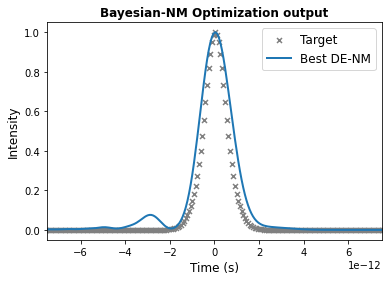

In [30]:
time, profile = l1_pump.forward_pass(optimized_solution)
fig, ax = plt.subplots()

ax.set_title("Bayesian-NM Optimization output", fontweight = "bold")
ax.scatter(losses.target_time, losses.target_profile, marker = "x", c = "grey", s = 25, label = "Target")
ax.plot(losses.target_time, np.roll(profile, - np.argmax(profile) + np.argmax(losses.target_profile)), label = "Best DE-NM", lw = 2)

ax.set_xlim(-7.5e-12, 7.5e-12); ax.set_xlabel("Time (s)", fontsize = 12); ax.set_ylabel("Intensity", fontsize = 12)
ax.legend(fontsize = 12)
plt.show()

In [31]:
# Initialize lists to store objective function values
objective_values = []
f_ev = []

# Define the bounds
bounds = np.array(((-5.31305788e-01, -4.17101926e-01), (-3.14772231e+08, 3.01620182e+08), (-2.55151879e+15, 1.56859005e+15)))

# Define the number of iterations and other parameters
num_iterations = 100
print_progress = 1

# Run optimization loop
for i in range(num_iterations):
    # Run Bayesian-NM optimization
    best_configuration, best_objective = bayesian_optimization(losses.lossb, bounds, n_iter=1, xi=0.02, decimal_precision1 = 5, decimal_precision2 = -2, decimal_precision3 = -3)
    optimized_solution, min_function_value, nfev, success, termination_reason, num_iterations, optimized_solutions = rounded_nelder_mead(losses.loss3, best_configuration, bounds, print_progress, decimal_precision1 = 3, decimal_precision2 = -5, decimal_precision3 = -13, maxiter=70)

    # Append objective value to list
    objective_values.append(min_function_value)
    f_ev.append(nfev)

# Calculate average and minimum objective function values
average_objective = np.mean(objective_values)
minimum_objective = np.min(objective_values)
average_fev = np.mean(f_ev)

# Print results
print("Average Objective Function Value:", average_objective)
print("Minimum Objective Function Value:", minimum_objective)
print("Average Number of Function Evaluations:", average_fev+201)

-31.741384781747946
iteration: 1
best value of objective function so far: 31.741384781747946
best candidate: [-4.7043000e-01 -1.3483800e+07  8.2802443e+14]
iteration: 2
best value of objective function so far: 31.741384781747946
best candidate: [-4.7043000e-01 -1.3483800e+07  8.2802443e+14]
iteration: 3
best value of objective function so far: 31.741384781747946
best candidate: [-4.7043000e-01 -1.3483800e+07  8.2802443e+14]
iteration: 4
best value of objective function so far: 31.741384781747946
best candidate: [-4.7043000e-01 -1.3483800e+07  8.2802443e+14]
iteration: 5
best value of objective function so far: 31.741384781747946
best candidate: [-4.7043000e-01 -1.3483800e+07  8.2802443e+14]
iteration: 6
best value of objective function so far: 31.741384781747946
best candidate: [-4.7043000e-01 -1.3483800e+07  8.2802443e+14]
iteration: 7
best value of objective function so far: 31.741384781747946
best candidate: [-4.7043000e-01 -1.3483800e+07  8.2802443e+14]
iteration: 8
best value of o

iteration: 11
best value of objective function so far: 6.215101152789843
best candidate: [-4.77e-01 -3.20e+06  1.40e+15]
iteration: 12
best value of objective function so far: 6.215101152789843
best candidate: [-4.77e-01 -3.20e+06  1.40e+15]
iteration: 13
best value of objective function so far: 4.6930640957079754
best candidate: [-4.76e-01 -1.09e+07  1.46e+15]
iteration: 14
best value of objective function so far: 4.5957305149621055
best candidate: [-4.75e-01 -8.80e+06  1.45e+15]
iteration: 15
best value of objective function so far: 3.250246439705618
best candidate: [-4.76e-01 -9.20e+06  1.49e+15]
iteration: 16
best value of objective function so far: 3.250246439705618
best candidate: [-4.76e-01 -9.20e+06  1.49e+15]
iteration: 17
best value of objective function so far: 3.250246439705618
best candidate: [-4.76e-01 -9.20e+06  1.49e+15]
iteration: 18
best value of objective function so far: 2.9635756298151303
best candidate: [-4.76e-01 -8.70e+06  1.46e+15]
iteration: 19
best value of o

iteration: 12
best value of objective function so far: 4.94128014933696
best candidate: [-4.76e-01 -1.15e+07 -8.70e+14]
iteration: 13
best value of objective function so far: 4.94128014933696
best candidate: [-4.76e-01 -1.15e+07 -8.70e+14]
iteration: 14
best value of objective function so far: 4.94128014933696
best candidate: [-4.76e-01 -1.15e+07 -8.70e+14]
iteration: 15
best value of objective function so far: 4.94128014933696
best candidate: [-4.76e-01 -1.15e+07 -8.70e+14]
iteration: 16
best value of objective function so far: 3.990785979645297
best candidate: [-4.76e-01 -8.60e+06 -7.30e+14]
iteration: 17
best value of objective function so far: 3.842752584455635
best candidate: [-4.76e-01 -1.02e+07 -8.10e+14]
iteration: 18
best value of objective function so far: 3.842752584455635
best candidate: [-4.76e-01 -1.02e+07 -8.10e+14]
iteration: 19
best value of objective function so far: 3.81385199416142
best candidate: [-4.76e-01 -1.02e+07 -9.30e+14]
iteration: 20
best value of objective

iteration: 9
best value of objective function so far: 13.385703626615586
best candidate: [-4.81e-01  3.00e+06 -3.20e+14]
iteration: 10
best value of objective function so far: 13.385703626615586
best candidate: [-4.81e-01  3.00e+06 -3.20e+14]
iteration: 11
best value of objective function so far: 13.385703626615586
best candidate: [-4.81e-01  3.00e+06 -3.20e+14]
iteration: 12
best value of objective function so far: 13.385703626615586
best candidate: [-4.81e-01  3.00e+06 -3.20e+14]
iteration: 13
best value of objective function so far: 13.385703626615586
best candidate: [-4.81e-01  3.00e+06 -3.20e+14]
iteration: 14
best value of objective function so far: 13.385703626615586
best candidate: [-4.81e-01  3.00e+06 -3.20e+14]
iteration: 15
best value of objective function so far: 9.718832110030394
best candidate: [-4.78e-01 -2.90e+06 -1.32e+15]
iteration: 16
best value of objective function so far: 8.748178913111373
best candidate: [-4.77e-01 -6.40e+06 -7.50e+14]
iteration: 17
best value of

iteration: 9
best value of objective function so far: 13.699143780027029
best candidate: [-4.77e-01  1.80e+06 -3.30e+14]
iteration: 10
best value of objective function so far: 4.265320400071613
best candidate: [-4.76e-01 -5.20e+06 -3.20e+14]
iteration: 11
best value of objective function so far: 4.265320400071613
best candidate: [-4.76e-01 -5.20e+06 -3.20e+14]
iteration: 12
best value of objective function so far: 4.265320400071613
best candidate: [-4.76e-01 -5.20e+06 -3.20e+14]
iteration: 13
best value of objective function so far: 4.265320400071613
best candidate: [-4.76e-01 -5.20e+06 -3.20e+14]
iteration: 14
best value of objective function so far: 4.265320400071613
best candidate: [-4.76e-01 -5.20e+06 -3.20e+14]
iteration: 15
best value of objective function so far: 4.265320400071613
best candidate: [-4.76e-01 -5.20e+06 -3.20e+14]
iteration: 16
best value of objective function so far: 3.1458132543170683
best candidate: [-4.75e-01 -8.20e+06 -2.40e+14]
iteration: 17
best value of obj

...

iteration: 59
best value of objective function so far: 2.488484425680289
best candidate: [-4.75e-01 -9.10e+06 -2.55e+15]
iteration: 60
best value of objective function so far: 2.488484425680289
best candidate: [-4.75e-01 -9.10e+06 -2.55e+15]
iteration: 61
best value of objective function so far: 2.488484425680289
best candidate: [-4.75e-01 -9.10e+06 -2.55e+15]
iteration: 62
best value of objective function so far: 2.488484425680289
best candidate: [-4.75e-01 -9.10e+06 -2.55e+15]
iteration: 63
best value of objective function so far: 2.488484425680289
best candidate: [-4.75e-01 -9.10e+06 -2.55e+15]
iteration: 64
best value of objective function so far: 2.488484425680289
best candidate: [-4.75e-01 -9.10e+06 -2.55e+15]
iteration: 65
best value of objective function so far: 2.488484425680289
best candidate: [-4.75e-01 -9.10e+06 -2.55e+15]
iteration: 66
best value of objective function so far: 2.488484425680289
best candidate: [-4.75e-01 -9.10e+06 -2.55e+15]
iteration: 67
best value of obje

iteration: 58
best value of objective function so far: 2.1512963587023215
best candidate: [-4.75e-01 -7.30e+06 -4.40e+14]
iteration: 59
best value of objective function so far: 2.1512963587023215
best candidate: [-4.75e-01 -7.30e+06 -4.40e+14]
iteration: 60
best value of objective function so far: 2.1512963587023215
best candidate: [-4.75e-01 -7.30e+06 -4.40e+14]
iteration: 61
best value of objective function so far: 2.1512963587023215
best candidate: [-4.75e-01 -7.30e+06 -4.40e+14]
-17.879647729982324
iteration: 1
best value of objective function so far: 17.879647729982324
best candidate: [-4.7585000e-01  2.3800000e+06 -9.1336801e+14]
iteration: 2
best value of objective function so far: 17.879647729982324
best candidate: [-4.7585000e-01  2.3800000e+06 -9.1336801e+14]
iteration: 3
best value of objective function so far: 17.879647729982324
best candidate: [-4.7585000e-01  2.3800000e+06 -9.1336801e+14]
iteration: 4
best value of objective function so far: 17.879647729982324
best candid

iteration: 66
best value of objective function so far: 3.545331200850681
best candidate: [-4.75e-01 -6.30e+06 -5.70e+14]
iteration: 67
best value of objective function so far: 3.545331200850681
best candidate: [-4.75e-01 -6.30e+06 -5.70e+14]
iteration: 68
best value of objective function so far: 3.545331200850681
best candidate: [-4.75e-01 -6.30e+06 -5.70e+14]
iteration: 69
best value of objective function so far: 3.545331200850681
best candidate: [-4.75e-01 -6.30e+06 -5.70e+14]
iteration: 70
best value of objective function so far: 3.545331200850681
best candidate: [-4.75e-01 -6.30e+06 -5.70e+14]
-28.119638851995052
iteration: 1
best value of objective function so far: 28.033669235744323
best candidate: [-4.73800000e-01 -4.03362000e+07  1.56859005e+15]
iteration: 2
best value of objective function so far: 28.033669235744323
best candidate: [-4.73800000e-01 -4.03362000e+07  1.56859005e+15]
iteration: 3
best value of objective function so far: 28.033669235744323
best candidate: [-4.7380

iteration: 64
best value of objective function so far: 6.124295881629265
best candidate: [-4.77e-01 -1.09e+07  8.10e+14]
iteration: 65
best value of objective function so far: 6.124295881629265
best candidate: [-4.77e-01 -1.09e+07  8.10e+14]
iteration: 66
best value of objective function so far: 6.124295881629265
best candidate: [-4.77e-01 -1.09e+07  8.10e+14]
iteration: 67
best value of objective function so far: 6.124295881629265
best candidate: [-4.77e-01 -1.09e+07  8.10e+14]
iteration: 68
best value of objective function so far: 6.124295881629265
best candidate: [-4.77e-01 -1.09e+07  8.10e+14]
iteration: 69
best value of objective function so far: 6.124295881629265
best candidate: [-4.77e-01 -1.09e+07  8.10e+14]
iteration: 70
best value of objective function so far: 6.124295881629265
best candidate: [-4.77e-01 -1.09e+07  8.10e+14]
-26.04120836570969
iteration: 1
best value of objective function so far: 26.04120836570969
best candidate: [-4.82240000e-01  1.64479000e+07 -2.36830772e+

iteration: 62
best value of objective function so far: 2.294666449531126
best candidate: [-4.75e-01 -8.70e+06 -1.96e+15]
iteration: 63
best value of objective function so far: 2.294666449531126
best candidate: [-4.75e-01 -8.70e+06 -1.96e+15]
iteration: 64
best value of objective function so far: 2.294666449531126
best candidate: [-4.75e-01 -8.70e+06 -1.96e+15]
iteration: 65
best value of objective function so far: 2.294666449531126
best candidate: [-4.75e-01 -8.70e+06 -1.96e+15]
iteration: 66
best value of objective function so far: 2.294666449531126
best candidate: [-4.75e-01 -8.70e+06 -1.96e+15]
iteration: 67
best value of objective function so far: 2.294666449531126
best candidate: [-4.75e-01 -8.70e+06 -1.96e+15]
iteration: 68
best value of objective function so far: 2.294666449531126
best candidate: [-4.75e-01 -8.70e+06 -1.96e+15]
iteration: 69
best value of objective function so far: 2.294666449531126
best candidate: [-4.75e-01 -8.70e+06 -1.96e+15]
iteration: 70
best value of obje